<a href="https://colab.research.google.com/github/ayushmanpathak9034/MLE-Case-Study-2/blob/main/MLE_CS_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Devansh Srivastava 202501100300091 AI B

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix
from imblearn.over_sampling import SMOTE
import xgboost as xgb

In [ ]:
df = pd.read_csv('/content/creditcard.csv')
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [ ]:
scaler = StandardScaler()
df['std_amount'] = scaler.fit_transform(df[['Amount']])
df['std_time'] = scaler.fit_transform(df[['Time']])

In [ ]:
df_filter = df.drop(columns=['Time', 'Amount'])

In [ ]:
df_filter.sample(5)

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V22,V23,V24,V25,V26,V27,V28,Class,std_amount,std_time
273989,-0.570852,1.279990,-0.475552,-1.194248,0.861286,-0.726196,0.994204,0.186604,-0.234806,-0.963085,...,-0.247845,-0.261835,-0.987431,0.064721,-0.056661,0.225641,0.143673,0,-0.335278,1.494863
276193,-0.243928,3.141374,-2.946971,5.045465,1.823447,1.195500,-1.379422,-5.200586,-2.696677,-0.797342,...,0.330570,0.251328,-1.529991,-0.349883,0.393080,-0.197983,0.022302,0,-0.316847,1.519016
238669,-7.520890,6.643416,-3.671242,-3.072673,-0.000284,-1.914825,2.036277,-0.806521,6.196710,10.795768,...,0.566346,0.063724,0.010097,1.180521,-0.007220,2.093676,0.566934,0,-0.335038,1.157178
38742,0.799735,-0.491541,0.419907,0.945636,-0.655507,-0.457268,0.228606,-0.119241,0.203286,-0.294126,...,-0.461518,-0.053765,0.440476,0.201580,0.199600,-0.042472,0.049508,0,0.446948,-1.164290
264101,-0.082845,0.983903,0.883923,0.987807,0.479347,-0.643126,0.851173,-0.497938,-0.497289,0.567948,...,-0.294740,-0.090350,0.113166,-0.653535,0.592365,0.122974,-0.004569,0,-0.346113,1.399344


In [ ]:
# Remove rows having missing Class values
df = df.dropna(subset=['Class'])

# Convert target to integer
df['Class'] = df['Class'].astype(int)

X = df.drop(columns=['Class'])
y = df['Class']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [ ]:
print(f"Original Training Set Size: {X_train.shape[0]}")
print(f"Original Training Fraud Count: {y_train.sum()}")

Original Training Set Size: 227845
Original Training Fraud Count: 394


In [ ]:
smote = SMOTE(random_state=42, k_neighbors=5)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

In [ ]:
print(f"Balanced Training Set Size (after SMOTE): {X_train_resampled.shape[0]}")
print(f"Balanced Training Fraud Count: {y_train_resampled.sum()}")

Balanced Training Set Size (after SMOTE): 454902
Balanced Training Fraud Count: 227451


In [ ]:
model = xgb.XGBClassifier(n_estimators=100,max_depth=6,learning_rate=0.1,objective='binary:logistic',eval_metric='logloss', random_state=42,n_jobs=-1)

In [ ]:
print("Training XGBoost model...")
model.fit(X_train_resampled, y_train_resampled)

Training XGBoost model...


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=-1,
              num_parallel_tree=None, ...)

In [ ]:
y_probs = model.predict_proba(X_test)[:, 1]

In [ ]:
thresholds = [0.1, 0.3, 0.5, 0.7, 0.9]
for threshold in thresholds:
    y_pred = (y_probs >= threshold).astype(int)

    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

    print(
        f"Threshold: {threshold:.1f} | "
        f"Precision: {precision:.4f} | "
        f"Recall: {recall:.4f} | "
        f"F1-Score: {f1:.4f} | "
        f"(TP: {tp}, FP: {fp}, FN: {fn})"
    )

Threshold: 0.1 | Precision: 0.1450 | Recall: 0.8980 | F1-Score: 0.2496 | (TP: 88, FP: 519, FN: 10)
Threshold: 0.3 | Precision: 0.3385 | Recall: 0.8878 | F1-Score: 0.4901 | (TP: 87, FP: 170, FN: 11)
Threshold: 0.5 | Precision: 0.5058 | Recall: 0.8878 | F1-Score: 0.6444 | (TP: 87, FP: 85, FN: 11)
Threshold: 0.7 | Precision: 0.6641 | Recall: 0.8673 | F1-Score: 0.7522 | (TP: 85, FP: 43, FN: 13)
Threshold: 0.9 | Precision: 0.7961 | Recall: 0.8367 | F1-Score: 0.8159 | (TP: 82, FP: 21, FN: 16)


<Figure size 1000x600 with 0 Axes>

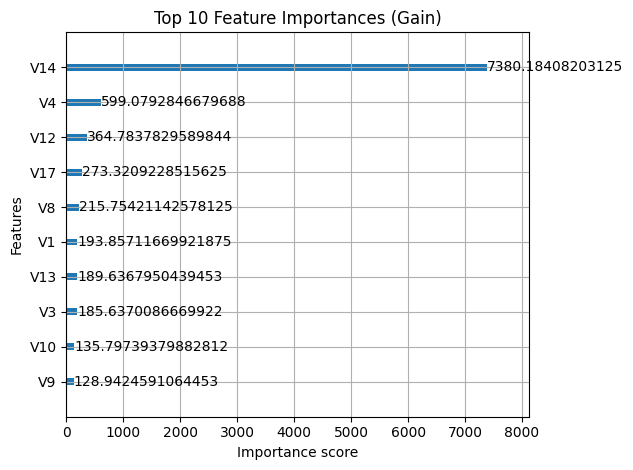

In [ ]:
plt.figure(figsize=(10, 6))
xgb.plot_importance(model, max_num_features=10, importance_type='gain', title='Top 10 Feature Importances (Gain)')
plt.tight_layout()
plt.show()